### 任务 1：THUCNews 中文分词 + 词频统计

In [ ]:
import os
import jieba
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# ====== 1. 选择数据路径 ======
data_dir = "THUCNews/家居"
files = os.listdir(data_dir)[:500]  # 只取前100篇，太多会很慢

# ====== 2. 读取所有文本 ======
texts = []
for fname in files:
    with open(os.path.join(data_dir, fname), 'r', encoding='utf-8') as f:
        texts.append(f.read())

# ====== 3. 中文分词 ======
# jieba.cut 会自动识别词边界
all_words = []
for text in texts:
    words = jieba.cut(text)
    all_words.extend(words)

# ====== 4. 去除停用词和单个字符 ======
stopwords = set(open("stopwords.txt", encoding="utf-8").read().split())
clean_words = [w for w in all_words if w not in stopwords and len(w) > 1]

# ====== 5. 统计词频 ======
word_freq = Counter(clean_words)
top_words = word_freq.most_common(25)
df = pd.DataFrame(top_words, columns=["word", "freq"])

# ====== 6. 可视化 ======
plt.figure(figsize=(10,6))
plt.bar(df["word"], df["freq"])
plt.title("Top 25 词频统计（家居类）")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    font_path="/System/Library/Fonts/STHeiti Light.ttc",  
    width=800, height=400, background_color="white",max_words=250,colormap='viridis'
).generate(" ".join(clean_words))

plt.imshow(wc)
plt.axis("off")
plt.show()


### 任务 2：英文文本预处理（以 IMDB 数据集为例）

#### 示例

In [1]:
import os
import nltk
import ssl

nltk_data_path = "/Users/zhangyuxin/Pycharm_Projects/py_works/cs224n/project1/nltk_data"
os.makedirs(nltk_data_path, exist_ok=True)
ssl._create_default_https_context = ssl._create_unverified_context

# 下载到指定目录
nltk.download('punkt', download_dir=nltk_data_path)
nltk.download('punkt_tab', download_dir=nltk_data_path)
nltk.download('stopwords', download_dir=nltk_data_path)
nltk.download('wordnet', download_dir=nltk_data_path)
nltk.download('punkt_tab', download_dir="/Users/zhangyuxin/Pycharm_Projects/py_works/cs224n/project1/nltk_data")


# 确保加载路径包含此目录
nltk.data.path.append(nltk_data_path)

print(nltk.data.path)


['/Users/zhangyuxin/nltk_data', '/Users/zhangyuxin/miniconda3/envs/cs224n/nltk_data', '/Users/zhangyuxin/miniconda3/envs/cs224n/share/nltk_data', '/Users/zhangyuxin/miniconda3/envs/cs224n/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data', '/Users/zhangyuxin/Pycharm_Projects/py_works/cs224n/project1/nltk_data']


[nltk_data] Downloading package punkt to /Users/zhangyuxin/Pycharm_Pro
[nltk_data]     jects/py_works/cs224n/project1/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/zhangyuxin/Pycharm
[nltk_data]     _Projects/py_works/cs224n/project1/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/zhangyuxin/Pycharm
[nltk_data]     _Projects/py_works/cs224n/project1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/zhangyuxin/Pycharm_P
[nltk_data]     rojects/py_works/cs224n/project1/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/zhangyuxin/Pycharm
[nltk_data]     _Projects/py_works/cs224n/project1/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
import string
import matplotlib.pyplot as plt
import pandas as pd

# ====== 1. 示例文本 ======
texts = [
    "The movie was absolutely wonderful! I loved every minute of it.",
    "It was boring and predictable. I almost fell asleep.",
    "Fantastic acting, but the story was too slow."
]

# ====== 2. 初始化工具 ======
stop_words = set(stopwords.words('english'))
custom_stop_words = {
    'movie', 'film', 'character', 'story', 'scene', 'plot',
    'one', 'time', 'make', 'see', 'get', 'like', 'good', 'bad',
    'really', 'even', 'also', 'much', 'well'
}
stop_words = stop_words.union(custom_stop_words)

lemmatizer = WordNetLemmatizer() # 初始化一个“词形还原器”

# ====== 3. 文本预处理 ======
all_words = []
for text in texts:
    # 分词并转小写
    tokens = word_tokenize(text.lower())
    # 去停用词 + 去标点
    filtered = [w for w in tokens if w not in stop_words and w not in string.punctuation]
    # 词形还原
    lemmas = [lemmatizer.lemmatize(w) for w in filtered]
    all_words.extend(lemmas)

# ====== 4. 统计词频 ======
word_freq = Counter(all_words)
df = pd.DataFrame(word_freq.most_common(15), columns=['word', 'freq'])

# ====== 5. 可视化 ======
plt.figure(figsize=(10,6))
plt.bar(df['word'], df['freq'])
plt.title("Top 15 Frequent Words (Sample English Reviews)")
plt.xticks(rotation=45)
plt.show()


#### IMDB数据集

In [ ]:
from datasets import load_dataset

# 加载 IMDB 数据集
dataset = load_dataset("imdb")

# 查看结构
print(dataset)
print(dataset['train'][0])


In [ ]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])
print(train_df.head())

In [ ]:
# 清理 + 分词 + 去停用词 + 词形还原 
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
import matplotlib.pyplot as plt

# 初始化工具
stop_words = set(stopwords.words('english'))
stop_words.update(string.punctuation)
# 扩展无意义词汇（语气词、助动词、符号、评论常见词）
custom_stop_words = {
    'movie', 'film', 'character', 'story', 'scene', 'plot',
    'one', 'time', 'make', 'see', 'get', 'like', 'good', 'bad',
    'really', 'even', 'also', 'much', 'well', 'br', 'would', 'could',
    'it', 's', 't', 'isn', 'wasn', 'didn', 'doesn', 'don', 'won',
    'll', 're', 've', 'amp', 'etc', 'thing', 'things', 'people',
    'go', 'going', 'come', 'came', 'show', 'first', 'way', 'still'
}
stop_words = stop_words.union(custom_stop_words)

lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    """对单条文本进行预处理"""
    tokens = word_tokenize(text.lower())  # 分词并转小写
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]  # 去停用词和标点
    lemmas = [lemmatizer.lemmatize(w) for w in filtered]  # 词形还原
    return lemmas

# 示例：预处理前1000条评论
sample_texts = train_df["text"][:1000]
all_words = []

for text in sample_texts:
    all_words.extend(preprocess_text(text))

print("样本中总词数：", len(all_words))
print("前20个词：", all_words[:20])


In [ ]:
# 统计词频
from collections import Counter
import pandas as pd

# 统计词频
word_freq = Counter(all_words)
df_freq = pd.DataFrame(word_freq.most_common(20), columns=['word', 'freq'])

# 可视化
plt.figure(figsize=(10,6))
plt.bar(df_freq['word'], df_freq['freq'], color='skyblue')
plt.title("Top 20 Most Frequent Words (IMDB sample)")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# 词云
from wordcloud import WordCloud

text_str = ' '.join(all_words)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_str)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


### 任务3: IMDB 正负情感评论的文本清洗 + 高频词对比分析

'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /datasets/imdb/resolve/main/README.md (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1017)')))"), '(Request ID: 5d7dc932-22c3-42ed-b0c6-cce0203a6e49)')' thrown while requesting HEAD https://huggingface.co/datasets/imdb/resolve/main/README.md
Retrying in 1s [Retry 1/5].
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /datasets/stanfordnlp/imdb/resolve/main/README.md (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1017)')))"), '(Request ID: 04115a25-41a6-4533-a081-4dbbe1825085)')' thrown while requesting HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/main/README.md
Retrying in 1s [Retry 1/5].


正面评论数量: 12500, 负面评论数量: 12500
正在处理正面评论...
正在处理负面评论...
处理完成！

最具正面倾向的词:
            word  freq_diff
0          love       1042
1          best        959
2          life        944
3            ha        717
4   performance        704
5          year        602
6     excellent        524
7          role        493
8         young        480
9     wonderful        457
10       family        444
11       always        432
12    beautiful        409
13        world        392
14         many        391

最具负面倾向的词:
         word  freq_diff
0         wa       2013
1      worst        822
2    nothing        672
3     minute        562
4      waste        500
5      awful        488
6        guy        486
7     stupid        460
8   terrible        439
9     better        434
10    script        426
11      poor        426
12    boring        410
13     least        398
14  supposed        391


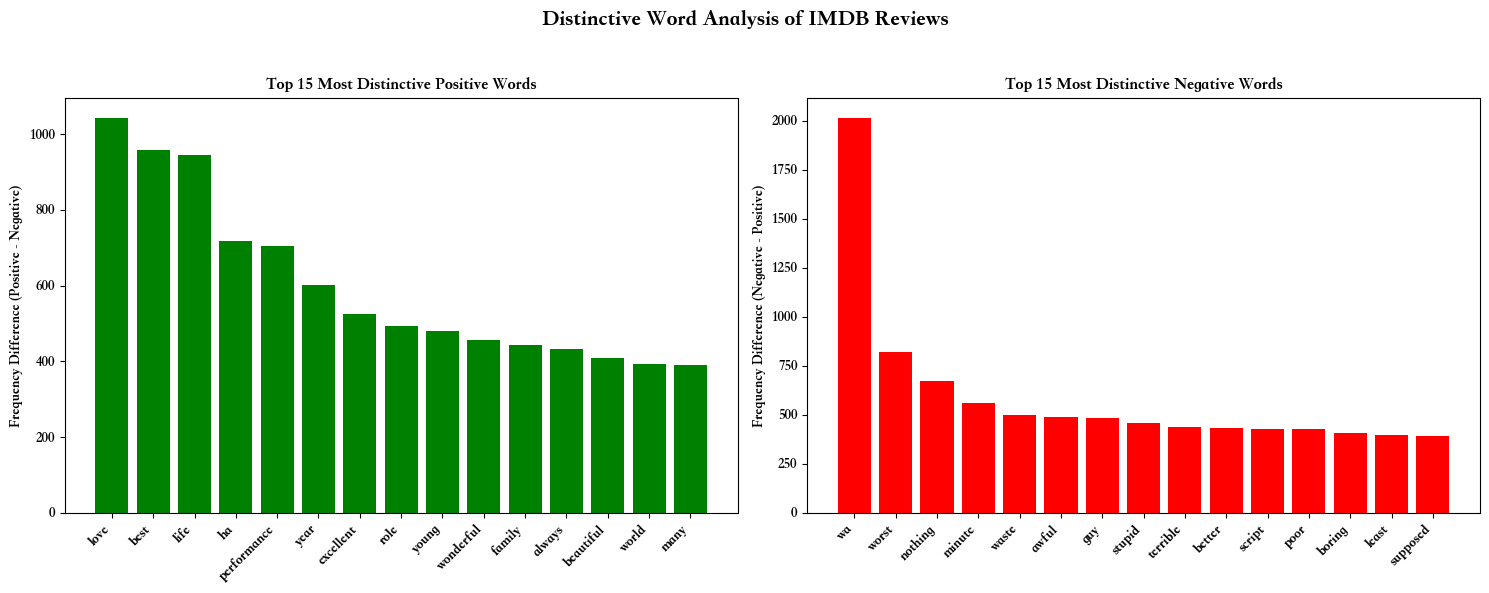

In [ ]:
from datasets import load_dataset
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# --- ✅ 1. 加载IMDB数据集 ---
dataset = load_dataset("imdb")
train_data = dataset["train"]
pos_texts = [x["text"] for x in train_data if x["label"] == 1]
neg_texts = [x["text"] for x in train_data if x["label"] == 0]
print(f"正面评论数量: {len(pos_texts)}, 负面评论数量: {len(neg_texts)}")

# --- ✅ 2. 初始化NLTK工具 ---
stop_words = set(stopwords.words('english'))
stop_words.update(string.punctuation)
# 自定义停用词列表，这次我们确保它能生效！
custom_stop_words = {
    'movie', 'film', 'character', 'story', 'scene', 'plot', 'actor', 'acting',
    'one', 'time', 'make', 'see', 'get', 'like', 'good', 'bad', 'great',
    'really', 'even', 'also', 'much', 'well', 'br', 'would', 'could', 'made',
    'it', 's', 't', 'isn', 'wasn', 'didn', 'doesn', 'don', 'won', 'say', 'know',
    'll', 're', 've', 'amp', 'etc', 'thing', 'things', 'people', 'look',
    'go', 'going', 'come', 'came', 'show', 'first', 'way', 'still'
}
stop_words = stop_words.union(custom_stop_words)
lemmatizer = WordNetLemmatizer() # Lemmatizer可以放在全局

# --- ✅ 3. 定义经过优化的预处理函数 ---
def preprocess(text_list):
    """
    优化的文本预处理流程:
    1. 分词并转小写
    2. 词形还原 (在去停用词之前！)
    3. 去除停用词和非字母词
    """
    all_words = []
    for text in text_list:
        tokens = word_tokenize(text.lower())
        # 先进行词形还原
        lemmas = [lemmatizer.lemmatize(w) for w in tokens]
        # 再用全局的停用词表进行过滤
        filtered = [w for w in lemmas if w.isalpha() and w not in stop_words]
        all_words.extend(filtered)
    return all_words

# --- ✅ 4. 对正负样本分别清洗 ---
print("正在处理正面评论...")
pos_words = preprocess(pos_texts[:5000])  # 可以适当增加样本量，如5000
print("正在处理负面评论...")
neg_words = preprocess(neg_texts[:5000])
print("处理完成！")

# --- ✅ 5. 🔥【核心升级】计算并分析差异性高频词 ---
pos_freq = Counter(pos_words)
neg_freq = Counter(neg_words)

# 获取所有独特的词
all_unique_words = set(pos_words) | set(neg_words) # 所有在正面或负面评论中出现过的不重复词语的集合。| 是集合的“并集”操作。

# 计算每个词的频率差值
word_diffs = {}
for word in all_unique_words:
    pos_count = pos_freq.get(word, 0)
    neg_count = neg_freq.get(word, 0)
    word_diffs[word] = pos_count - neg_count
# 如果词存在，就返回它的计数值；如果不存在（比如某个词只在负面评论里出现过），就返回 0，这样可以避免程序出错。
# 用正面次数减去负面次数，得到一个“差值”。如果一个词主要是正面词（如 wonderful），这个差值会是一个很大的正数。如果一个词主要是负面词（如 awful），这个差值会是一个很大的负数。如果一个词是中性词，两边出现差不多，差值就接近于0。

# 排序并找出差异最大的词
# reverse=True 意味着从大到小排序，找出正面倾向最强的词
sorted_pos_diff = sorted(word_diffs.items(), key=lambda item: item[1], reverse=True) # 差值最大的（最正面的）词就会排在最前面。
# 默认从小到大排序，找出负面倾向最强的词 (差值为大的负数)
sorted_neg_diff = sorted(word_diffs.items(), key=lambda item: item[1])

# 转换为DataFrame用于绘图
df_pos_diff = pd.DataFrame(sorted_pos_diff[:15], columns=['word', 'freq_diff'])
df_neg_diff = pd.DataFrame(sorted_neg_diff[:15], columns=['word', 'freq_diff'])
# 对于负面词，我们取绝对值来绘图，更直观
df_neg_diff['freq_diff'] = df_neg_diff['freq_diff'].abs() 

print("\n最具正面倾向的词:\n", df_pos_diff)
print("\n最具负面倾向的词:\n", df_neg_diff)


# --- ✅ 6. 可视化差异性高频词 ---
plt.figure(figsize=(15, 6)) # 画布可以更宽一点

# 绘制正面倾向词
plt.subplot(1, 2, 1)
plt.bar(df_pos_diff["word"], df_pos_diff["freq_diff"], color='green')
plt.title("Top 15 Most Distinctive Positive Words")
plt.ylabel("Frequency Difference (Positive - Negative)")
plt.xticks(rotation=45, ha="right")

# 绘制负面倾向词
plt.subplot(1, 2, 2)
# 注意这里我们画的是 df_neg_diff
plt.bar(df_neg_diff["word"], df_neg_diff["freq_diff"], color='red') 
plt.title("Top 15 Most Distinctive Negative Words")
plt.ylabel("Frequency Difference (Negative - Positive)")
plt.xticks(rotation=45, ha="right")

plt.suptitle("Distinctive Word Analysis of IMDB Reviews", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # 调整布局以适应总标题
plt.show()

### 任务4: 中英文混合文本处理

模拟社交媒体评论（例如中英文混写）；

自定义正则表达式清洗文本（去表情、去特殊字符、URL）；

分别统计中英文词频。


--- 中文Top10 ---
  word  freq
0   新出     1
1  太棒了     1
2   推荐     1
3   剧情     1
4   拖沓     1
5   差劲     1
6   今天     1
7   学了     1
8   好多     1
9   技术     1

--- 英文Top10 ---
     word  freq
0  camera     1
1   movie     1
2   total     1
3   waste     1
4    time     1
5  acting     1
6   skill     1
7     set     1
8   happy     1
9     omg     1


[nltk_data] Downloading package punkt to /Users/zhangyuxin/Pycharm_Pro
[nltk_data]     jects/py_works/cs224n/project1/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/zhangyuxin/Pycharm
[nltk_data]     _Projects/py_works/cs224n/project1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/zhangyuxin/Pycharm_P
[nltk_data]     rojects/py_works/cs224n/project1/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


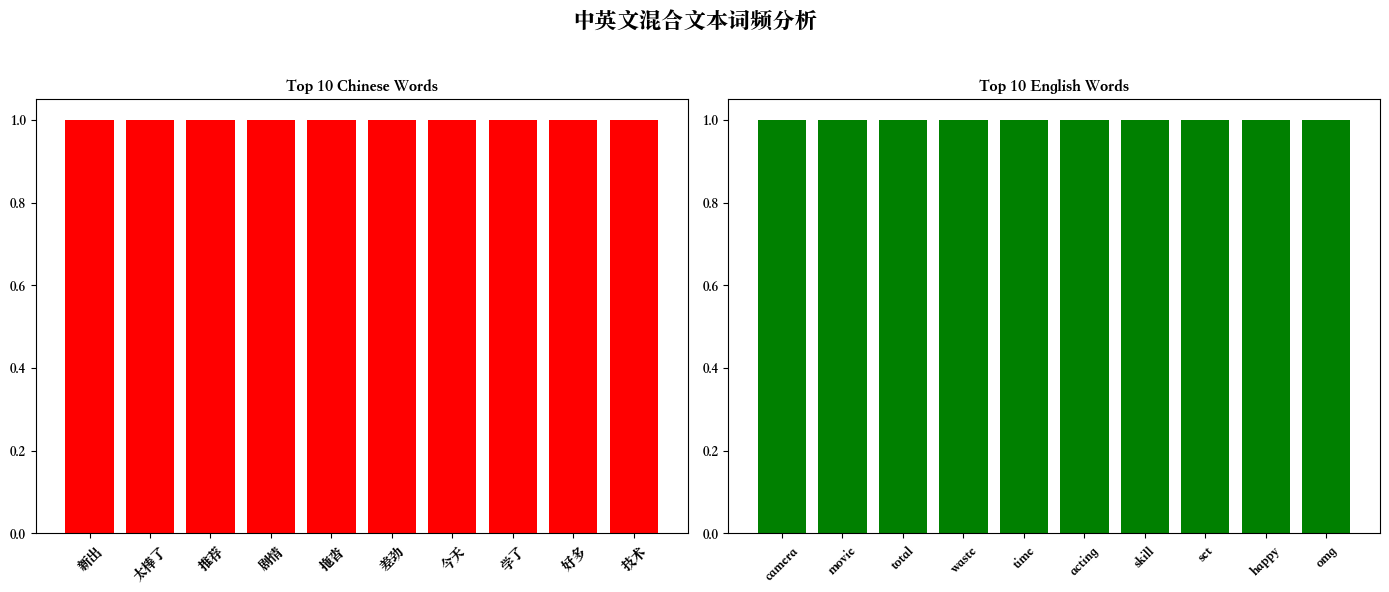

In [4]:
import os
import ssl
import re
import jieba
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib

# ✅ 直接强制使用可显示中文的系统字体
matplotlib.rcParams['font.family'] = 'Songti SC'
matplotlib.rcParams['axes.unicode_minus'] = False  # 让负号正常显示

import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize



# ========== ✅ 1. NLTK 初始化 ==========
nltk_data_path = "/Users/zhangyuxin/Pycharm_Projects/py_works/cs224n/project1/nltk_data"
os.makedirs(nltk_data_path, exist_ok=True)
ssl._create_default_https_context = ssl._create_unverified_context

nltk.download('punkt', download_dir=nltk_data_path)
nltk.download('stopwords', download_dir=nltk_data_path)
nltk.download('wordnet', download_dir=nltk_data_path)
nltk.data.path.append(nltk_data_path)

# ========== ✅ 2. 模拟数据 ==========
sample_texts = [
    "这个新出的camera太棒了！推荐给大家👍 https://example.com/product123",
    "This movie is a total waste of time... 剧情拖沓，acting也很差劲👎",
    "今天学了好多 #NLP 技术，感觉自己的skill set又提升了！ happy 😄",
    "OMG, a new paper on transformer models is out! 我要去拜读一下... @ProfLi",
    "哈哈哈哈😂 a really funny joke! 笑死我了",
    "The food here is just so-so. 中文的评价是：味道一般般，性价比不高。",
    "Just finished my workout, feeling great and powerful! 💪",
    "这个项目deadline临近，压力山大啊... need more coffee ☕️"
]

# ========== ✅ 3. 停用词 ==========
eng_stop_words = set(stopwords.words('english'))
chi_stop_words = set()
if os.path.exists("stopwords.txt"):
    chi_stop_words = set(open("stopwords.txt", encoding="utf-8").read().split())
else:
    print("⚠️ 未找到 stopwords.txt，将使用空中文停用词表")

lemmatizer = WordNetLemmatizer()

# ========== ✅ 4. 文本清洗 ==========
def clean_text(text):
    text = re.sub(r"http\S+|www\S+", "", text)  # 去URL
    text = re.sub(r"[@#][\w_]+", "", text)  # 去@或话题
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub('', text)
    text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9\s]', '', text)
    return text.strip()

# ========== ✅ 5. 中英文分词 ==========
def split_texts(texts):
    chi_words, eng_words = [], []

    for t in texts:
        t = clean_text(t)
        chi_part = ''.join(re.findall(r'[\u4e00-\u9fa5]+', t))
        eng_part = ' '.join(re.findall(r'[a-zA-Z]+', t))

        # 中文分词
        chi_tokens = [w for w in jieba.cut(chi_part) if w not in chi_stop_words and len(w) > 1]
        chi_words.extend(chi_tokens)

        # 英文分词 + 词形还原
        eng_tokens = [lemmatizer.lemmatize(w.lower()) for w in word_tokenize(eng_part)
                      if w.lower() not in eng_stop_words and w.isalpha()]
        eng_words.extend(eng_tokens)

    return chi_words, eng_words

chi_words, eng_words = split_texts(sample_texts)

# ========== ✅ 6. 统计词频 ==========
chi_df = pd.DataFrame(Counter(chi_words).most_common(10), columns=["word", "freq"])
eng_df = pd.DataFrame(Counter(eng_words).most_common(10), columns=["word", "freq"])

print("\n--- 中文Top10 ---")
print(chi_df)
print("\n--- 英文Top10 ---")
print(eng_df)

# ========== ✅ 7. 可视化 ==========
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 6))
plt.suptitle("中英文混合文本词频分析", fontsize=16)

plt.subplot(1, 2, 1)
plt.bar(chi_df["word"], chi_df["freq"], color='red')
plt.title("Top 10 Chinese Words")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(eng_df["word"], eng_df["freq"], color='green')
plt.title("Top 10 English Words")
plt.xticks(rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### 任务5: 进阶——制作自己的词袋模型（Bag-of-Words）

要求：

使用上一步处理好的文本；

生成词袋向量；

构造 DataFrame，展示每篇文本的词频特征；

选做：使用 sklearn.feature_extraction.text.CountVectorizer 和 TfidfVectorizer 比较结果差异。

#### 在 IMDB 数据集上实现 BoW 和 TF-IDF

In [ ]:
# --- ✅ 1. 准备工作：加载数据与英文预处理 ---
import pandas as pd
import nltk # 自然语言处理工具包
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from datasets import load_dataset
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer # sklearn 自带的文本向量化工具

# --- 加载数据集并选取样本 ---
SAMPLE_SIZE = 2000 # 设定我们处理的样本数量
dataset = load_dataset("imdb")
# 从训练集中只取出前 SAMPLE_SIZE 条评论
train_data = dataset["train"][:SAMPLE_SIZE]
imdb_texts = train_data["text"] # 这是一个包含2000条评论原文的列表

print(f"成功加载 IMDB 数据集，我们将处理其中的 {SAMPLE_SIZE} 条评论。")

# --- 准备英文处理工具 ---
eng_stop_words = set(stopwords.words('english'))
# 我们可以加入一些在IMDB评论中常见但无意义的词，比如 'br' (HTML换行符)
eng_stop_words.add('br') 
lemmatizer = WordNetLemmatizer()

# --- 专门为IMDB准备的预处理函数 ---
def preprocess_imdb_sentence(text):
    """处理单条英文IMDB评论，返回一个干净的词列表"""
    # 转小写并分词
    tokens = word_tokenize(text.lower())
    
    # 词形还原并过滤停用词/非字母词
    lemmas = [lemmatizer.lemmatize(w) for w in tokens 
              if w not in eng_stop_words and w.isalpha()]
              
    return lemmas

# 对所有IMDB示例文本进行预处理
processed_imdb_texts = [preprocess_imdb_sentence(t) for t in imdb_texts]

print("\n--- IMDB 前3条评论预处理后的结果 ---")
for i in range(3):
    print(f"文档 {i}: {processed_imdb_texts[i]}")

# --- ✅ 2. 手动实现词袋模型 (Bag-of-Words) ---

# 1. 构建词汇表 (Vocabulary)
vocabulary = sorted(list(set(word for doc in processed_imdb_texts for word in doc)))
print(f"\n--- 构建的词汇表大小: {len(vocabulary)} ---") # 注意看，词汇表会大很多！
# 把所有评论的单词合并成集合（去重），然后排序

# 2. 创建词语到索引的映射
word_to_idx = {word: i for i, word in enumerate(vocabulary)}
# enumerate(vocabulary) 会产生一堆 (索引, 词) 的配对。

# 3. 生成词袋向量
bow_vectors = []
for doc in processed_imdb_texts:
    vector = [0] * len(vocabulary)
    doc_word_counts = Counter(doc)
    for word, count in doc_word_counts.items():
        if word in word_to_idx:
            idx = word_to_idx[word]
            vector[idx] = count
    bow_vectors.append(vector)

# 4. 构造 DataFrame 进行展示 (⚠️ 只展示部分结果)
df_bow_imdb = pd.DataFrame(bow_vectors, columns=vocabulary)

print("\n--- 手动实现的 IMDB 词袋模型 (BoW) ---")
print("DataFrame 尺寸:", df_bow_imdb.shape)
print("展示前5篇文档，前10个词的词频:")
# 使用 .iloc[:行数, :列数] 来展示一个巨大的DataFrame的子集
print(df_bow_imdb.iloc[:5, :10])


# --- ✅ 3. 【推荐】使用 sklearn 实现 BoW 和 TF-IDF ---

# 准备 sklearn 的输入：字符串列表
corpus_for_sklearn = [" ".join(doc) for doc in processed_imdb_texts]

# --- 1. 使用 CountVectorizer (BoW) ---
count_vectorizer = CountVectorizer()
bow_sklearn = count_vectorizer.fit_transform(corpus_for_sklearn)

print("\n--- sklearn 实现的词袋模型 (CountVectorizer) ---")
print("生成的稀疏矩阵尺寸:", bow_sklearn.shape)

# 转换为DataFrame进行展示 (同样只展示部分)
df_bow_sklearn_imdb = pd.DataFrame(
    bow_sklearn.toarray(), 
    columns=count_vectorizer.get_feature_names_out()
)
print("DataFrame 尺寸:", df_bow_sklearn_imdb.shape)
print("展示前5篇文档，部分词的词频:")
# 我们可以只看一些有代表性的词
# 注意：列名可能和我们手动实现的不一样，因为sklearn有自己的排序方式
print(df_bow_sklearn_imdb.iloc[:5, 1000:1010])


# --- 2. 使用 TfidfVectorizer ---
# TF-IDF（词频-逆文档频率）是一种改进的 BoW：每个词的权重 = 词频 × 逆文档频率，频繁出现在所有文档的词权重会变低（如 “the”, “movie”）。
tfidf_vectorizer = TfidfVectorizer()
tfidf_sklearn = tfidf_vectorizer.fit_transform(corpus_for_sklearn)

print("\n--- sklearn 实现的 TF-IDF 模型 ---")
print("生成的稀疏矩阵尺寸:", tfidf_sklearn.shape)

# 转换为DataFrame进行展示
df_tfidf_sklearn_imdb = pd.DataFrame(
    tfidf_sklearn.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
print("DataFrame 尺寸:", df_tfidf_sklearn_imdb.shape)
print("展示前5篇文档，部分词的 TF-IDF 权重:")
print(df_tfidf_sklearn_imdb.iloc[:5, 1000:1010])

成功加载 IMDB 数据集，我们将处理其中的 2000 条评论。

--- IMDB 前3条评论预处理后的结果 ---
文档 0: ['rented', 'video', 'store', 'controversy', 'surrounded', 'first', 'released', 'also', 'heard', 'first', 'seized', 'custom', 'ever', 'tried', 'enter', 'country', 'therefore', 'fan', 'film', 'considered', 'controversial', 'really', 'see', 'plot', 'centered', 'around', 'young', 'swedish', 'drama', 'student', 'named', 'lena', 'want', 'learn', 'everything', 'life', 'particular', 'want', 'focus', 'attention', 'making', 'sort', 'documentary', 'average', 'swede', 'thought', 'certain', 'political', 'issue', 'vietnam', 'war', 'race', 'issue', 'united', 'state', 'asking', 'politician', 'ordinary', 'denizen', 'stockholm', 'opinion', 'politics', 'sex', 'drama', 'teacher', 'classmate', 'married', 'kill', 'year', 'ago', 'considered', 'pornographic', 'really', 'sex', 'nudity', 'scene', 'far', 'even', 'shot', 'like', 'cheaply', 'made', 'porno', 'countryman', 'mind', 'find', 'shocking', 'reality', 'sex', 'nudity', 'major', 'staple', 'swe

| 方法           | 向量类型     | 稀疏性  | 是否考虑语义 | 是否考虑上下文 | 优点    | 缺点        |
| ------------ | -------- | ---- | ------ | ------- | ----- | --------- |
| **BoW**      | 词频向量     | 高度稀疏 | ❌ 否    | ❌ 否     | 简单快速  | 无语义、维度高   |
| **TF–IDF**   | 加权词频     | 稀疏   | ❌ 否    | ❌ 否     | 区分常见词 | 无语义信息     |
| **Word2Vec** | 稠密向量（低维） | 稠密   | ✅ 是    | ✅ 是     | 捕捉语义  | 需要训练、不可解释 |
